[README](README.md) | [Introduction](Introduction.md) | [Datasets](Datasets.md) | [Tasks](Tasks.md) | [Task 1](Task-1.md) | [Task 2](Task-2.md) | Notebook

# AS Centrality

In [1]:
name = "YOUR NAME HERE"
date = "MM/DD/YYYY"

In [2]:
%pip install -q requests pytricia pandas matplotlib pybgpkit-parser

import gc
import math
import time
import shutil
import multiprocessing as mp
from pathlib import Path
from collections import defaultdict, Counter

import requests
import pytricia
import pandas as pd
import matplotlib.pyplot as plt
import pybgpkit_parser as bgpkit

Note: you may need to restart the kernel to use updated packages.


## Task 1: Prepare data

### Task 1.1: Obtain BGP data

In the [BGP assignment](https://github.com/CAIDA/nids-bgp-control-plane), you fetched BGP Routing Information Base (RIB) snapshots from a *single* collector managed by [RouteViews](https://www.routeviews.org/routeviews/). This time, you will fetch the same type of data from *multiple* collectors, managed by [RIPE RIS](https://www.ripe.net/analyse/internet-measurements/routing-information-service-ris/). 

Using data from more collectors allows for a richer view of the Internet's structure at the cost of requiring significantly more computing power. When first writing your code, you can use `COLLECTORS = ["rrc06"]` so that the notebook executes more quickly. When answering the questions for the tasks, use the larger set of data with `COLLECTORS = ["rrc00", "rrc15", "rrc23"]`.

| Collector | Location | File size |
|---|---|---|
| `rrc00` | Amsterdam, NL | ~404 MB |
| `rrc06` | Otemachi, JP | ~41 MB |
| `rrc15` | São Paolo, BR | ~137 MB |
| `rrc23` | Singapore, SG | ~81 MB |

In [3]:
# COLLECTORS = ["rrc06"]                        # Uncomment for testing (41 MB)
COLLECTORS = ["rrc00", "rrc15", "rrc23"]    # Uncomment for full analysis
SNAPSHOT_DATE = "20260801"                    # YYYYMMDD
SNAPSHOT_HOUR = "0000"                        # 0000, 0800, 1600 UTC

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_rib_file(collector, date=None, hour=None):
    """
    Download a RIB file into data directory if not already cached;
    Return file path.
    """
    date = date or SNAPSHOT_DATE
    hour = hour or SNAPSHOT_HOUR
    fname = f"bview.{collector}.{date}.{hour}.gz"
    fpath = DATA_DIR / f"{fname}"
    if fpath.exists():
        print(f"Found in cache: {fname}")
    else:
        fpath.parent.mkdir(parents=True, exist_ok=True)
        download_url = (
            f"https://data.ris.ripe.net/"
            f"{collector}/{date[:4]}.{date[4:6]}/bview.{date}.{hour}.gz"
        )
        with requests.get(download_url, stream=True) as resp:
            resp.raise_for_status()
            with open(fpath, "wb") as fout:
                shutil.copyfileobj(resp.raw, fout)
        print(f"Downloaded: {fname}")
    return fpath

RIB_PATHS = [ fetch_rib_file(c) for c in COLLECTORS ]
print("Fetched all RIB files.")

Found in cache: bview.rrc00.20260801.0000.gz
Found in cache: bview.rrc15.20260801.0000.gz
Found in cache: bview.rrc23.20260801.0000.gz
Fetched all RIB files.


### Task 1.2: Obtain AS-organization mapping

In [4]:
ASNAMES_URL = "https://ftp.ripe.net/ripe/asnames/asn.txt"
fname = "asnames.txt"
fpath = DATA_DIR / f"{fname}"

if not fpath.exists():
    with requests.get(ASNAMES_URL, stream=True) as resp:
        resp.raise_for_status()
        with open(fpath, "w", encoding="utf-8") as fout:
            fout.write(resp.text)
    print(f"Downloaded: {fname}")

try:
    data = {}
    with open(fpath, "r", encoding="utf-8") as fin:
        for line in fin:
            asn, _ , rest = line.strip().partition(" ")
            name, _ , country = rest.rpartition(", ")
            data[asn] = {"name": name, "country": country}
except Exception as e: 
    print(f"An error occurred: {e}")

# store ASN-name mapping in a dataframe
as_info_df = pd.DataFrame.from_dict(data, orient='index', columns=['name','country'])
as_info_df.head(10)

,name,country
1,"LVLT-1 - Level 3 Parent, LLC",US
2,UDEL-DCN - University of Delaware,US
3,MIT-GATEWAYS - Massachusetts Institute of Tech...,US
4,ISI-AS - University of Southern California,US
5,SYMBOLICS - WFA Group LLC,US
6,"BULL-HN - ATOS IT Solutions and Services, Inc.",US
7,DSTL - The Defence Science and Technology Labo...,EU
8,RICE-AS - Rice University,US
9,CMU-ROUTER - Carnegie Mellon University,US
10,CSNET-EXT-AS - CSNET Coordination and Informat...,US


## Task 2: Convert RIB data into a weighted graph

Conceptually, BC and hegemony treat ASes and AS paths as vertices and edges in a graph. In this task, you will process the RIB files that you just fetched, and extract AS path information for later use. 

You might want to refer to the [bgpkit documentation](https://docs.rs/bgpkit-parser/latest/bgpkit_parser).

### Task 2.1: Compute address space size

This function is based on `count_addresses_per_asn(ipv4_single_origin)` in the BGP assignment. 

The main change is that we count the number of addresses within a prefix, not within an ASN. We call the number of addresses the weight of a given prefix. 

In [5]:
def get_address_count(pfx):
    pfx_len = 32 - int(pfx.split("/")[1])
    return 1 << pfx_len
    
def weigh_prefixes(pyt):
    """
    Assign weights to each observed prefix by the size of its address space.
    No double counting (see task description). 
    """
    pfx_to_weight = {}
    
    for pfx in pyt:
        pfx_weight = get_address_count(pfx)
        children_weight = 0
        for child in pyt.children(pfx):
            if pyt.parent(child) == pfx:
                children_weight += get_address_count(child)
        pfx_to_weight[pfx] = pfx_weight - children_weight
        
    return pfx_to_weight

### Task 2.2: Build local graphs

In [ ]:
def build_local_views(RIB_PATHS):
    """
    For each peer, we build a local graph of all the AS paths that it observes.
    We define 'full_path' as an AS path from peer's ASN to origin ASN. 
    We define 'atom' as an AS path excluding its origin AS.
    
    Each element returned by bgpkit parser represents a RIB table entry with the
    following format. For example:
    {
        'elem_type': 'R', 
        'peer_asn': 1234,
        'peer_address': '80.77.16.114',
        'as-path': '1234 956 14068',
        'origin': 14068,
        'prefix': '216.163.136.0/24'
    }
    
    TODO: Probably need to convert nested defaultdicts in local_graphs
    to regular dicts. 
    TODO: Should ignore MOAS prefixes or somehow deal with it.
    """
    pyt = pytricia.PyTricia(32)            # radix tree for prefix weighing later
    local_graphs = defaultdict(lambda: defaultdict(set))  # single peer views
    peer_to_asn = defaultdict(set)         # map a peer to every ASN it observes
    asn_to_peer = defaultdict(set)         # map an ASN to every peer that sees it
    unique_paths = set()
    n_processed = 0                        # progress report 

    for p in RIB_PATHS:
        for element in bgpkit.Parser(url=str(p)):
            if element.elem_type != "A": # only process route announcements
                continue
            o_pfx = element.prefix
            if ":" in o_pfx or o_pfx.endswith("/0"): # skip v6 and default routes
                continue
            
            pyt.insert(o_pfx, 0)

            full_path = element.as_path.split(" ")
            atom = tuple(full_path[:-1])
            o_asn = full_path[0]
            
            # update peer's view
            peer_ip = element.peer_ip
            local_graphs[peer_ip][atom].add((o_asn, o_pfx))

            peer_to_asn[peer_ip].update(full_path)
            for asn in full_path:
                asn_to_peer[asn].add(peer_ip)
            
            unique_paths.add((atom, o_asn, o_pfx))

            n_processed += 1
            if n_processed % 5_000_000 == 0: 
                print(f"...Processed {n_processed:,} entries")
                
    print(f"\nProcessed {n_processed:,} RIB entries across {len(RIB_PATHS):,} snapshot(s).")
    return pyt, dict(local_graphs), dict(peer_to_asn), dict(asn_to_peer), unique_paths

In [7]:
pyt, local_graphs, peer_to_asn, asn_to_peer, unique_paths = build_local_views(RIB_PATHS)
pfx_to_weight = weigh_prefixes(pyt)

n_prefix = len(pfx_to_weight)
all_asn = set(asn_to_peer.keys())
all_peer = set(peer_to_asn.keys())
observed_addrs = sum(pfx_to_weight.values())

print(f"Observed {len(all_asn):,} ASNs.")
print(f"Observed IPv4 address space: {observed_addrs:,} addresses "
      f"by {len(all_peer):,} peers from collector(s): {', '.join(COLLECTORS)}.")
print(f"Weighted {n_prefix:,} prefixes.")

...Processed 5,000,000 entries
...Processed 10,000,000 entries
...Processed 15,000,000 entries
...Processed 20,000,000 entries
...Processed 25,000,000 entries
...Processed 30,000,000 entries
...Processed 35,000,000 entries
...Processed 40,000,000 entries
...Processed 45,000,000 entries
...Processed 50,000,000 entries
...Processed 55,000,000 entries
...Processed 60,000,000 entries
...Processed 65,000,000 entries
...Processed 70,000,000 entries

Processed 70,168,671 RIB entries across 3 snapshot(s).
Observed 79,988 ASNs.
Observed IPv4 address space: 3,129,899,221 addresses by 127 peers from collector(s): rrc00, rrc15, rrc23.
Weighted 1,168,495 prefixes.


## Task 3: Compute betweenness centrality

### Task 3.1: Compute BC score for every ASN

In [10]:
def compute_bc_scores(unique_paths, pfx_to_weight, all_asn):
    """
    TODO: Finish function description.
    
    E.g., we consider the following as two different paths: 
    A -> B -> C (10.0.1.0/24)
    A -> B -> C (10.0.2.0/24)
    """
    total_observed_path_uw = len(unique_paths)
    total_observed_path_w = sum(pfx_to_weight[o_pfx] for _, _, o_pfx in unique_paths)
    path_with_asn_uw = defaultdict(int)
    path_with_asn_w = defaultdict(float)

    for atom, o_asn, o_pfx in unique_paths:
        full_path = set(atom)
        full_path.add(o_asn)

        weight = pfx_to_weight[o_pfx]
        for asn in full_path:
            path_with_asn_uw[asn] += 1
            path_with_asn_w[asn] += weight

    bc_scores = defaultdict(lambda: {"uw" : 0.0, "w" : 0.0})
    for asn in all_asn:
        bc_scores[asn] = {
            "uw": path_with_asn_uw[asn] / total_observed_path_uw,
            "w": path_with_asn_w[asn] / total_observed_path_w,
        }

    return bc_scores

bc_scores = compute_bc_scores(unique_paths, pfx_to_weight, all_asn)

### Task 3.2: Summarize BC data

In [21]:
bc_df = pd.DataFrame.from_dict(bc_scores, orient="index")

bc_df_enriched = (
    bc_df
    .merge(as_info_df, left_index=True, right_index=True)
    .reset_index(names="asn")
    .assign(
        uw_rank=lambda df: df['uw'].rank(ascending=False).astype(int),
        w_rank=lambda df: df['w'].rank(ascending=False).astype(int)
    )
    .reindex(columns=["w_rank","uw_rank","asn","name","country","uw","w"])
    .sort_values("w", ascending=False)
    .reset_index(drop=True)
)

bc_df_enriched.head(15)

,w_rank,uw_rank,asn,name,country,uw,w
0,1,2,3356,"LEVEL3 - Level 3 Parent, LLC",US,0.166255,0.238074
1,2,3,1299,TWELVE99 Arelion Sweden AB,SE,0.157147,0.175508
2,3,1,6939,HURRICANE - Hurricane Electric LLC,US,0.166476,0.132875
3,4,4,174,"COGENT-174 - Cogent Communications, LLC",US,0.143210,0.132267
4,5,5,2914,"NTT-DATA-2914 - NTT America, Inc.",US,0.070985,0.082275
5,6,7,58057,SECUREBIT Securebit AG,CH,0.056343,0.058192
6,7,6,9002,RETN-AS RETN Limited,GB,0.056769,0.051819
7,8,9,34549,MEER-AS meerfarbig GmbH & Co. KG,DE,0.045065,0.048198
8,9,8,3257,GTT-BACKBONE GTT Communications Inc.,US,0.049983,0.043121
9,10,11,6762,SEABONE-NET TELECOM ITALIA SPARKLE S.p.A.,IT,0.042859,0.041361


### Question 1
What does betweenness centrality measure?

### Question 2
Why would we use the weighted betweenness centrality versus the unweighted betweenness centrality?

### Question 3
What are the top 5 ASes ranked by their weighted betweenness centralities? How these compare to the top ASes [as ranked by customer cone size](https://asrank.caida.org/)? Does this make sense? Why?

### Task 3.3: Distribution of betweenness centrality across ASes

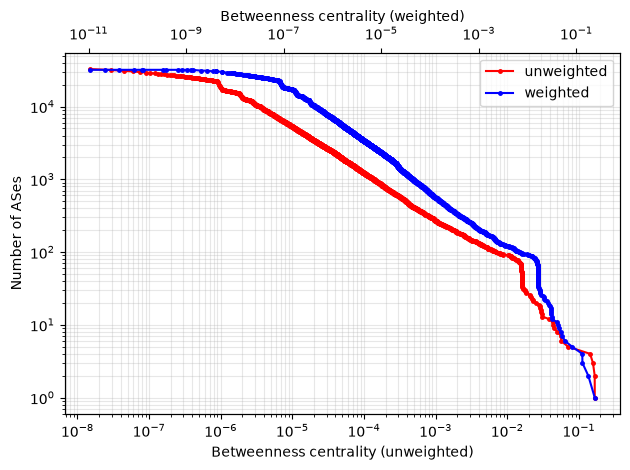

In [13]:
"""
CCDF for unweighted betweenness centrality.
TODO: add some hints. 
"""
bc_uw_list = [v for v in bc_df_enriched["uw"] if v > 0]
bc_uw_dist = Counter(bc_uw_list)
x_bc_uw = sorted(bc_uw_dist.keys())
y_bc_uw = []
remaining = len(bc_uw_list)
for xi in x_bc_uw:
    y_bc_uw.append(remaining)
    remaining -= bc_uw_dist[xi]

"""
CCDF for weighted betweenness centrality.
TODO: add some hints.
"""
bc_w_list = [v for v in bc_df_enriched["w"] if v > 0]
bc_w_dist = Counter(bc_w_list)
x_bc_w = sorted(bc_w_dist.keys())
y_bc_w = []
remaining = len(bc_w_list)
for xi in x_bc_w:
    y_bc_w.append(remaining)
    remaining -= bc_w_dist[xi]

fig, ax1 = plt.subplots()
ax1.plot(x_bc_uw, y_bc_uw, marker=".", markersize=5, color="red", label="unweighted")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Betweenness centrality (unweighted)")
ax1.set_ylabel("Number of ASes")

ax2 = ax1.twiny()
ax2.plot(x_bc_w, y_bc_w, marker=".", markersize=5, color="blue", label="weighted")
ax2.set_xscale("log")
ax2.set_xlabel("Betweenness centrality (weighted)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
ax1.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

### Question 4
What shape does the CCDF have? What does this tell us about the distribution of weighted betweenness centralities?

YOUR ANSWER HERE

## Task 4: Compute hegemony

In this task you will:

1. Compute $BC_{(j)}(v)$ for each viewpoint $j$ and AS $v$;
2. Filter out VPs and compute quotients to calculate AS hegemony;
3. Create a scatter plot of AS hegemony vs. weighted betweenness centrality;
4. Answer some questions about the data.

In [14]:
def _bc_for_every_asn_per_peer(atom_to_origins, pfx_to_weight):
    total_observed_path_uw = 0
    total_observed_path_w = 0.0
    path_with_asn_uw = defaultdict(int)
    path_with_asn_w = defaultdict(float)

    for atom, origin_asn_pfx_pairs in atom_to_origins.items():
        for o_asn, o_pfx in origin_asn_pfx_pairs:
            weight = pfx_to_weight[o_pfx]
            total_observed_path_uw += 1
            total_observed_path_w += weight

            asns_in_path = set(atom)
            asns_in_path.add(o_asn)

            for asn in asns_in_path:
                path_with_asn_uw[asn] += 1
                path_with_asn_w[asn] += weight
            
    peer_scores = {}
    for asn in path_with_asn_uw:
        peer_scores[asn] = (
            path_with_asn_uw[asn] / total_observed_path_uw,
            path_with_asn_w[asn] / total_observed_path_w,
        )
        
    return peer_scores


In [15]:
def compute_hegemony_scores(local_graphs, pfx_to_weight, asn_to_peer, peer_to_asn):
    """
    Drop the top 10 percent and bottom 10 percent of viewpoints.
    """
    ALPHA = 0.1
    all_asn = set(asn_to_peer.keys())
    all_peer = set(peer_to_asn.keys())
    n_drop = int(len(all_peer) * ALPHA)
    hege_scores = defaultdict(lambda: {"uw": 0.0, "w": 0.0})

    peer_scores = {}
    for peer, atom_to_origins in local_graphs.items():
        peer_scores[peer] = _bc_for_every_asn_per_peer(atom_to_origins, pfx_to_weight)

    for target_asn in all_asn:
        bc_score_lst_uw = []
        bc_score_lst_w = []

        for peer in all_peer:
            if peer in peer_scores and target_asn in peer_scores[peer]:
                bc_uw, bc_w = peer_scores[peer][target_asn]
            else:
                bc_uw, bc_w = 0.0, 0.0
            bc_score_lst_uw.append(bc_uw)
            bc_score_lst_w.append(bc_w)

        bc_score_lst_uw.sort()
        bc_score_lst_w.sort()

        if n_drop > 0:
            bc_score_lst_uw = bc_score_lst_uw[n_drop:-n_drop]
            bc_score_lst_w = bc_score_lst_w[n_drop:-n_drop]
        
        hege_scores[target_asn]["uw"] = (
            sum(bc_score_lst_uw) / len(bc_score_lst_uw) if bc_score_lst_uw else 0.0
        )
        hege_scores[target_asn]["w"] = (
            sum(bc_score_lst_w) / len(bc_score_lst_w) if bc_score_lst_w else 0.0
        )

    return dict(hege_scores)

hege = compute_hegemony_scores(local_graphs, pfx_to_weight, asn_to_peer, peer_to_asn)

### Task 3.2: Summarize hegemony data

In [20]:
hege_df = pd.DataFrame.from_dict(hege, orient="index")

hege_df_enriched = (
    hege_df
    .merge(as_info_df, left_index=True, right_index=True)
    .reset_index(names="asn")
    .assign(
        uw_rank=lambda df: df["uw"].rank(ascending=False).astype(int),
        w_rank=lambda df: df["w"].rank(ascending=False).astype(int)
    )
    .reindex(columns=["w_rank","uw_rank","asn","name","country","uw","w"])
    .sort_values("w", ascending=False)
    .reset_index(drop=True)
)
hege_df_enriched.head(15)

,w_rank,uw_rank,asn,name,country,uw,w
0,1,2,3356,"LEVEL3 - Level 3 Parent, LLC",US,0.054297,0.088243
1,2,1,6939,HURRICANE - Hurricane Electric LLC,US,0.059063,0.037622
2,3,3,1299,TWELVE99 Arelion Sweden AB,SE,0.039806,0.037494
3,4,4,174,"COGENT-174 - Cogent Communications, LLC",US,0.035696,0.024723
4,5,34,16509,"AMAZON-02 - Amazon.com, Inc.",US,0.002748,0.020080
5,6,5,2914,"NTT-DATA-2914 - NTT America, Inc.",US,0.019521,0.016438
6,7,15,721,DNIC-ASBLK-00721-00726 - United States Departm...,US,0.006063,0.011427
7,8,10,6762,SEABONE-NET TELECOM ITALIA SPARKLE S.p.A.,IT,0.010760,0.009452
8,9,14,12956,TELXIUS TELEFONICA GLOBAL SOLUTIONS SL,ES,0.006478,0.008538
9,10,26,701,UUNET - Verizon Business,US,0.003439,0.008130


### Question 1
Why do we remove the top and bottom $\alpha$ proportions of the viewpoints?

YOUR ANSWER HERE

### Question 2
How do the top 5 ASes ranked by betweenness centrality compare to the top 5 ranked by AS hegemony?

YOUR ANSWER HERE

### Task 4.3: Compare BC and hegemony data

In [23]:
compare_df = (
    hege_df
    .merge(bc_df, left_index=True, right_index=True, suffixes=("_hege", "_bc"))
    .merge(as_info_df, left_index=True, right_index=True)
    .reset_index(names="asn")
    .assign(
        uw_hege_rank=lambda df: df["uw_hege"].rank(ascending=False).astype(int),
        w_hege_rank=lambda df: df["w_hege"].rank(ascending=False).astype(int),
        uw_bc_rank=lambda df: df["uw_bc"].rank(ascending=False).astype(int),
        w_bc_rank=lambda df: df["w_bc"].rank(ascending=False).astype(int),
    )
    .reindex(columns=[
        "asn","name","country",
        "uw_hege","w_hege",
        "uw_bc","w_bc",
        "uw_hege_rank","w_hege_rank",
        "uw_bc_rank","w_bc_rank"
    ])
    .sort_values("w_hege_rank", ascending=True)
    .reset_index(drop=True)
)

rank_df = (
    compare_df[[
        "w_hege_rank","w_bc_rank",
        "asn","name","country",
    ]]
)
rank_df.head(15)

,w_hege_rank,w_bc_rank,asn,name,country
0,1,1,3356,"LEVEL3 - Level 3 Parent, LLC",US
1,2,3,6939,HURRICANE - Hurricane Electric LLC,US
2,3,2,1299,TWELVE99 Arelion Sweden AB,SE
3,4,4,174,"COGENT-174 - Cogent Communications, LLC",US
4,5,11,16509,"AMAZON-02 - Amazon.com, Inc.",US
5,6,5,2914,"NTT-DATA-2914 - NTT America, Inc.",US
6,7,23,721,DNIC-ASBLK-00721-00726 - United States Departm...,US
7,8,10,6762,SEABONE-NET TELECOM ITALIA SPARKLE S.p.A.,IT
8,9,20,12956,TELXIUS TELEFONICA GLOBAL SOLUTIONS SL,ES
9,10,24,701,UUNET - Verizon Business,US


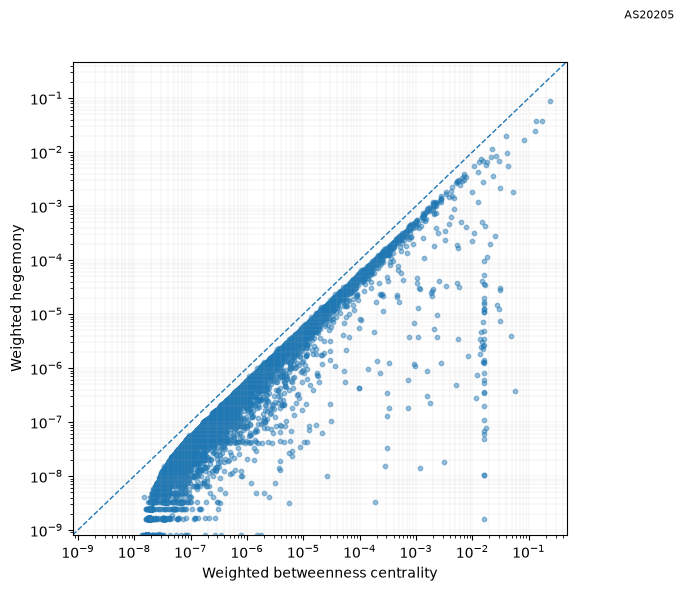

In [18]:
pos = compare_df[(compare_df["w_bc"] > 0) & (compare_df["w_hege"] > 0)]

fig, ax = plt.subplots(figsize=(7, 6))

lo = min(pos["w_bc"].min(), pos["w_hege"].min())
hi = max(pos["w_bc"].max(), pos["w_hege"].max()) * 2
ax.plot([lo, hi], [lo, hi], linewidth=1, linestyle="--")

ax.scatter(pos["w_bc"], pos["w_hege"], s=10, alpha=0.45)

asn_outlier = pos.iloc[(pos["w_bc"] / pos["w_hege"]).argmax()]
ax.annotate(f"AS{asn_outlier['asn']}", xy=(asn_outlier["w_bc"], asn_outlier["w_hege"]),
            xytext=(5, 3), fontsize=8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.grid(True, which="major", linewidth=0.2, alpha=0.5)
ax.grid(True, which="minor", linewidth=0.2, alpha=0.5)
ax.set_xlabel("Weighted betweenness centrality")
ax.set_ylabel("Weighted hegemony")
fig.tight_layout()
plt.show()

### Question 3
What does the concentration of points on the $x = y$ line tell us about the relationship between betweenness centrality and AS hegemony?

YOUR ANSWER HERE

### Question 4
Look up the AS that corresponds to the outlier point. How does this AS's geographic location relate to the location of the collectors?

YOUR ANSWER HERE

### Question 5
Why does the geographic location of the outlier AS cause its betweenness centrality to be so much larger than its AS hegemony?

YOUR ANSWER HERE